# 06 · เพิ่มพยากรณ์ฝนเป็น feature เพื่อทำนายล่วงหน้า 3–5 วัน

notebook 04 พบว่าโมเดลทำนายล่วงหน้า 3–5 วันไม่ดีกว่า persistence และถ้ารู้ฝนอนาคตจริงจะดีขึ้นมาก
notebook นี้ใส่ **พยากรณ์ฝนที่มีอยู่จริง ณ วันที่ออกพยากรณ์** จาก Open-Meteo Previous Runs (ECMWF IFS, GFS) เข้าไปแทน

**ปัญหา:** พยากรณ์ฝนในอดีตแยกตามวันล่วงหน้ามีตั้งแต่ มี.ค. 2024 เท่านั้น — สั้นเกินกว่าจะเทรนโดยตรง

**แนวทาง (perfect prognosis):**
1. **ตอนเทรน** (2020–2023) ใช้ฝนที่ตกจริง (ERA5) เป็นค่า `rain_next{h}d` → โมเดลเรียนว่า "ถ้าฝนตกเท่านี้ น้ำจะขึ้นเท่าไร"
2. **ตอนใช้งาน/ทดสอบ** ใส่พยากรณ์ฝนจริงแทน → ผลบน test สะท้อนการใช้งานจริง
3. **ปรับ bias** ของพยากรณ์ให้ตรงกับระดับฝน ERA5 โดยใช้ข้อมูลปี 2024 (ไม่แตะ test)
4. ใช้ run ที่ **เก่ากว่าวันออกพยากรณ์ 1 วัน** (เช่น ฝนวัน t+3 มาจาก run ที่ออก 4 วันก่อน) เพื่อให้แน่ใจว่าเป็นข้อมูลที่มีจริง ณ สิ้นวัน t
5. เลือกแบบจำลองฝนและ horizon ที่ใช้ฝนด้วย **validation 2024** แล้ววัดผลบน **test 2025–2026** ครั้งเดียว

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy
import pandas
from IPython.display import display

from mojito import config, evaluation, features, models

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
NWP_MODELS = {"ecmwf_ifs025": "ECMWF IFS", "gfs_seamless": "GFS"}
HORIZONS = features.HORIZONS
BEST_PARAMS = {"ridge_delta": {"alpha": 1}, "lgbm_delta": {"num_leaves": 7, "min_child_samples": 10}}  # จาก notebook 04

table = pandas.read_parquet(config.DATA_DIR / "processed" / "features_daily.parquet")
nwp_daily = features.nwp_daily_rain(pandas.read_parquet(config.RAW_DIR / "nwp_rain_previous_runs.parquet"))
for model in NWP_MODELS:
    table = features.add_forecast_rain(table, nwp_daily, model)
FEATURES = features.feature_columns(table)

forecast_period = table[f"nwp_ecmwf_ifs025_rain_next5d"].notna()
print(f"มีพยากรณ์ฝนครบ 5 วัน: {forecast_period.sum()} วัน "
      f"({table.index[forecast_period].min():%Y-%m-%d} ถึง {table.index[forecast_period].max():%Y-%m-%d})")

มีพยากรณ์ฝนครบ 5 วัน: 939 วัน (2024-02-29 ถึง 2026-09-29)


## 1 · พยากรณ์ฝนแม่นแค่ไหน
เทียบฝนสะสมเฉลี่ยลุ่มน้ำ t+1…t+h ที่พยากรณ์ไว้ กับฝน ERA5 ที่ตกจริง (มี.ค. 2024 – ปัจจุบัน)

correlation       ฝนพยากรณ์ / ฝนจริง       เฉพาะฝนจริง ≥ 100 มม.  \
แบบจำลอง   ECMWF IFS   GFS          ECMWF IFS   GFS             ECMWF IFS   
h                                                                           
1               0.63  0.55               0.85  0.72                  0.19   
2               0.69  0.61               0.86  0.71                  0.34   
3               0.72  0.67               0.86  0.72                  0.33   
4               0.74  0.68               0.86  0.63                  0.34   
5               0.76  0.69               0.83  0.56                  0.37   

                
แบบจำลอง   GFS  
h               
1         0.20  
2         0.38  
3         0.45  
4         0.39  
5         0.36

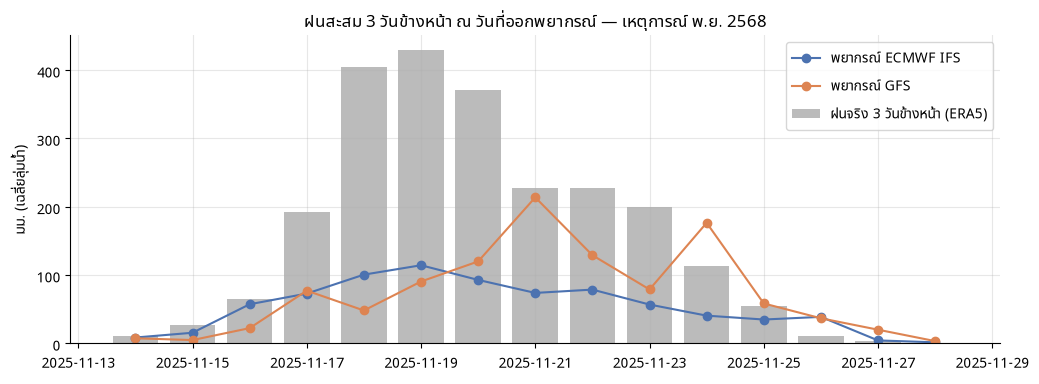

In [2]:
skill = []
period = table[forecast_period]
for model, label in NWP_MODELS.items():
    for h in HORIZONS:
        pair = period[[f"oracle_rain_next{h}d", f"nwp_{model}_rain_next{h}d"]].dropna()
        actual, forecast = pair.iloc[:, 0], pair.iloc[:, 1]
        heavy = actual >= 100
        skill.append({
            "แบบจำลอง": label, "h": h,
            "correlation": actual.corr(forecast),
            "ฝนพยากรณ์ / ฝนจริง": forecast.sum() / actual.sum(),
            "เฉพาะฝนจริง ≥ 100 มม.": forecast[heavy].sum() / actual[heavy].sum(),
        })
skill = pandas.DataFrame(skill)
display(skill.pivot(index="h", columns="แบบจำลอง").round(2))

event = table.loc["2025-11-14":"2025-11-28"]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(event.index, event["oracle_rain_next3d"], color="#bbbbbb", label="ฝนจริง 3 วันข้างหน้า (ERA5)")
for model, color in zip(NWP_MODELS, ["#4c72b0", "#dd8452"]):
    ax.plot(event.index, event[f"nwp_{model}_rain_next3d"], marker="o", color=color, label=f"พยากรณ์ {NWP_MODELS[model]}")
ax.set_ylabel("มม. (เฉลี่ยลุ่มน้ำ)")
ax.set_title("ฝนสะสม 3 วันข้างหน้า ณ วันที่ออกพยากรณ์ — เหตุการณ์ พ.ย. 2568")
ax.legend()
plt.show()

พยากรณ์ทั้งสองแบบจำลอง **เห็นว่าฝนกำลังจะหนัก แต่ให้ปริมาณต่ำกว่าจริงมาก** โดยเฉพาะวันฝนตกหนัก
จึงปรับ bias ด้วยตัวคูณ = ฝนจริงรวม / ฝนพยากรณ์รวม ของช่วง มี.ค.–ธ.ค. 2024 (validation) แยกตาม horizon

In [3]:
calibration = table.loc["2024-03-01":features.VALIDATION_END]
SCALE = {
    model: {h: float(calibration[f"oracle_rain_next{h}d"].sum() / calibration[f"nwp_{model}_rain_next{h}d"].sum())
            for h in HORIZONS}
    for model in NWP_MODELS
}
display(pandas.DataFrame(SCALE).rename(columns=NWP_MODELS).rename_axis("h").round(2))


def rain_inputs(frame, horizon):
    """Candidate values for the `rain_next{h}d` feature."""
    inputs = {"ไม่ใช้ฝน": None, "ฝนจริง (oracle)": frame[f"oracle_rain_next{horizon}d"]}
    scaled = []
    for model, label in NWP_MODELS.items():
        raw = frame[f"nwp_{model}_rain_next{horizon}d"]
        inputs[f"{label}"] = raw
        inputs[f"{label} ปรับ bias"] = raw * SCALE[model][horizon]
        scaled.append(raw * SCALE[model][horizon])
    inputs["เฉลี่ย 2 แบบจำลอง ปรับ bias"] = sum(scaled) / len(scaled)
    return inputs


def evaluate(fit_frame, eval_frame, model_names=("ridge_delta", "lgbm_delta")):
    rows, predictions = [], {}
    for h in HORIZONS:
        rain_feature = f"rain_next{h}d"
        with_rain = FEATURES + [rain_feature]
        fit_with_oracle = fit_frame.assign(**{rain_feature: fit_frame[f"oracle_rain_next{h}d"]})
        for name in model_names:
            plain = models.HorizonModel(name, h, FEATURES, BEST_PARAMS[name]).fit(fit_frame)
            rain_model = models.HorizonModel(name, h, with_rain, BEST_PARAMS[name]).fit(fit_with_oracle)
            for input_name, values in rain_inputs(eval_frame, h).items():
                if values is None:
                    prediction = plain.predict(eval_frame)
                else:
                    prediction = rain_model.predict(eval_frame.assign(**{rain_feature: values}))
                predictions[(name, input_name, h)] = prediction
                rows.append({"model": name, "ฝนที่ใส่": input_name, "h": h,
                             **evaluation.scores(prediction, eval_frame, h)})
    return pandas.DataFrame(rows), predictions

,ECMWF IFS,GFS
h,,
1,1.20,1.35
2,1.21,1.38
3,1.19,1.38
4,1.18,1.58
5,1.22,1.75


## 2 · เลือกแบบจำลองฝนด้วย validation (มี.ค.–ธ.ค. 2024)
เทรนบน 2020–2023 วัดบนช่วง validation ที่มีพยากรณ์ฝน (มีเหตุการณ์ใกล้ล้นตลิ่ง พ.ย. 2567)

In [4]:
train = table[table["split"] == "train"]
validation = table[(table["split"] == "validation") & forecast_period]
validation_results, _ = evaluate(train, validation)

pivot = validation_results.pivot_table(index=["model", "ฝนที่ใส่"], columns="h", values="MAE วันน้ำหลาก")
display(pivot.round(2))

# Choose with ridge (the model the web uses), on horizons 2-5, never the oracle
candidates = pivot.loc["ridge_delta"].drop(index=["ฝนจริง (oracle)", "ไม่ใช้ฝน"])
CHOSEN_INPUT = candidates[[2, 3, 4, 5]].mean(axis=1).idxmin()
# Per horizon: use rain only where it beat the no-rain model on validation
ridge_validation = pivot.loc["ridge_delta"]
USE_RAIN = {h: bool(ridge_validation.loc[CHOSEN_INPUT, h] < ridge_validation.loc["ไม่ใช้ฝน", h]) for h in HORIZONS}
print("แบบจำลองฝนที่เลือก:", CHOSEN_INPUT)
print("ใช้ฝนพยากรณ์ใน horizon:", [h for h, use in USE_RAIN.items() if use])

h                                           1     2     3     4     5
model       ฝนที่ใส่                                                 
lgbm_delta  ECMWF IFS                    1.03  1.91  2.79  3.28  3.61
            ECMWF IFS ปรับ bias          1.00  1.91  2.44  3.20  3.50
            GFS                          1.04  2.04  2.44  3.06  3.60
            GFS ปรับ bias                1.03  2.03  2.59  3.01  3.16
            ฝนจริง (oracle)              0.93  1.63  1.77  2.07  2.51
            เฉลี่ย 2 แบบจำลอง ปรับ bias  0.99  1.98  2.56  3.01  3.15
            ไม่ใช้ฝน                     1.05  2.04  2.68  3.32  3.69
ridge_delta ECMWF IFS                    0.80  1.63  2.47  2.87  3.16
            ECMWF IFS ปรับ bias          0.76  1.56  2.34  2.74  3.02
            GFS                          0.79  1.65  2.33  2.83  3.28
            GFS ปรับ bias                0.72  1.52  2.03  2.53  2.87
            ฝนจริง (oracle)              0.67  1.28  1.73  1.68  1.85
            เฉลี่ย 2 แบบจำลอง ปรับ bias  0.74  1.54  2.17  2.57  2.94
            ไม่ใช้ฝน                     0.77  1.71  2.64  3.05  3.49

แบบจำลองฝนที่เลือก: GFS ปรับ bias
ใช้ฝนพยากรณ์ใน horizon: [1, 2, 3, 4, 5]


## 3 · ผลบน test (2025–2026) — เทรนใหม่บน 2020–2024

In [5]:
train_validation = table[table["split"] != "test"]
test = table[table["split"] == "test"]
test_results, test_predictions = evaluate(train_validation, test)

shown = ["ไม่ใช้ฝน", CHOSEN_INPUT, "ฝนจริง (oracle)"]
for metric in ["MAE วันน้ำหลาก", "MAE ทุกวัน"]:
    display(test_results[test_results["ฝนที่ใส่"].isin(shown)]
            .pivot_table(index=["model", "ฝนที่ใส่"], columns="h", values=metric)
            .reindex(shown, level=1).round(2).rename_axis(columns=f"{metric} (ม.) · h ="))

persistence_mae = {h: evaluation.scores(evaluation.persistence(test, h), test, h)["MAE วันน้ำหลาก"] for h in HORIZONS}
print("persistence MAE วันน้ำหลาก:", {h: round(v, 2) for h, v in persistence_mae.items()})

MAE วันน้ำหลาก (ม.) · h =       1     2     3     4     5
model       ฝนที่ใส่                                     
lgbm_delta  ไม่ใช้ฝน         0.86  1.87  3.36  4.49  5.18
            GFS ปรับ bias    1.10  1.59  2.51  3.37  3.80
            ฝนจริง (oracle)  0.78  0.96  1.45  2.32  2.84
ridge_delta ไม่ใช้ฝน         0.68  1.65  3.06  4.14  4.73
            GFS ปรับ bias    0.80  1.47  2.33  3.10  3.63
            ฝนจริง (oracle)  0.59  1.05  1.18  1.47  1.39

MAE ทุกวัน (ม.) · h =           1     2     3     4     5
model       ฝนที่ใส่                                     
lgbm_delta  ไม่ใช้ฝน         0.11  0.19  0.25  0.30  0.34
            GFS ปรับ bias    0.11  0.18  0.23  0.28  0.31
            ฝนจริง (oracle)  0.11  0.17  0.21  0.25  0.28
ridge_delta ไม่ใช้ฝน         0.10  0.17  0.25  0.31  0.35
            GFS ปรับ bias    0.11  0.17  0.23  0.29  0.32
            ฝนจริง (oracle)  0.10  0.16  0.20  0.23  0.25

persistence MAE วันน้ำหลาก: {1: np.float64(1.35), 2: np.float64(2.51), 3: np.float64(3.61), 4: np.float64(4.24), 5: np.float64(4.78)}


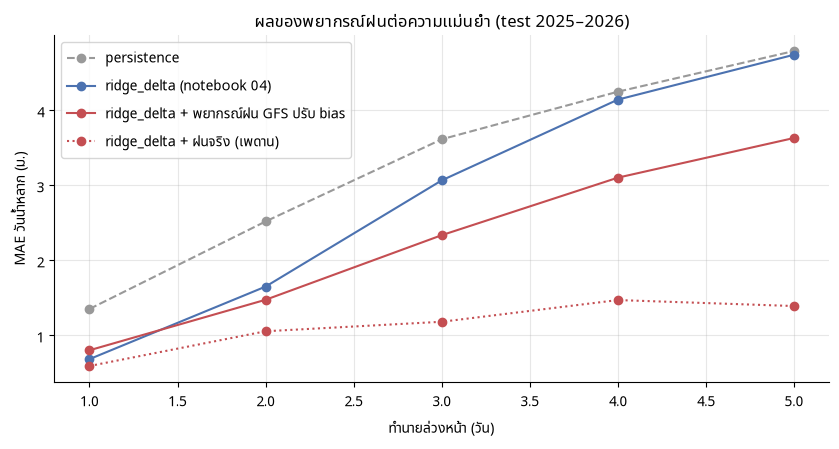

วันที่ระดับจริง ≥ 7.4 ม. ในชุด test: 6 วัน


เตือนถูก                     เตือนผิด            \
h                                  1    2    3    4    5        1    2    3   
model       ฝนที่ใส่                                                          
lgbm_delta  ไม่ใช้ฝน             5.0  4.0  0.0  0.0  0.0      0.0  1.0  1.0   
            GFS ปรับ bias        5.0  4.0  2.0  1.0  0.0      0.0  1.0  1.0   
            ฝนจริง (oracle)      5.0  4.0  3.0  2.0  0.0      0.0  1.0  1.0   
ridge_delta ไม่ใช้ฝน             4.0  3.0  0.0  0.0  0.0      0.0  0.0  1.0   
            GFS ปรับ bias        4.0  4.0  2.0  1.0  0.0      0.0  0.0  0.0   
            ฝนจริง (oracle)      4.0  4.0  3.0  2.0  3.0      0.0  0.0  0.0   

                                       
h                              4    5  
model       ฝนที่ใส่                   
lgbm_delta  ไม่ใช้ฝน         0.0  0.0  
            GFS ปรับ bias    1.0  1.0  
            ฝนจริง (oracle)  0.0  0.0  
ridge_delta ไม่ใช้ฝน         0.0  0.0  
            GFS ปรับ bias    1.0  0.0  
            ฝนจริง (oracle)  0.0  0.0

In [6]:
ridge = test_results[test_results["model"] == "ridge_delta"].pivot(index="h", columns="ฝนที่ใส่", values="MAE วันน้ำหลาก")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(HORIZONS, [persistence_mae[h] for h in HORIZONS], color="#999999", ls="--", marker="o", label="persistence")
ax.plot(ridge.index, ridge["ไม่ใช้ฝน"], color="#4c72b0", marker="o", label="ridge_delta (notebook 04)")
ax.plot(ridge.index, ridge[CHOSEN_INPUT], color="#c44e52", marker="o", label=f"ridge_delta + พยากรณ์ฝน {CHOSEN_INPUT}")
ax.plot(ridge.index, ridge["ฝนจริง (oracle)"], color="#c44e52", ls=":", marker="o", label="ridge_delta + ฝนจริง (เพดาน)")
ax.set_xlabel("ทำนายล่วงหน้า (วัน)")
ax.set_ylabel("MAE วันน้ำหลาก (ม.)")
ax.set_title("ผลของพยากรณ์ฝนต่อความแม่นยำ (test 2025–2026)")
ax.legend()
plt.show()

alerts = test_results[test_results["ฝนที่ใส่"].isin(shown)].pivot_table(
    index=["model", "ฝนที่ใส่"], columns="h", values=["เตือนถูก", "เตือนผิด"]).reindex(shown, level=1)
print(f"วันที่ระดับจริง ≥ {evaluation.FLOOD_M} ม. ในชุด test: {test_results['วันท่วมจริง'].iloc[0]} วัน")
alerts

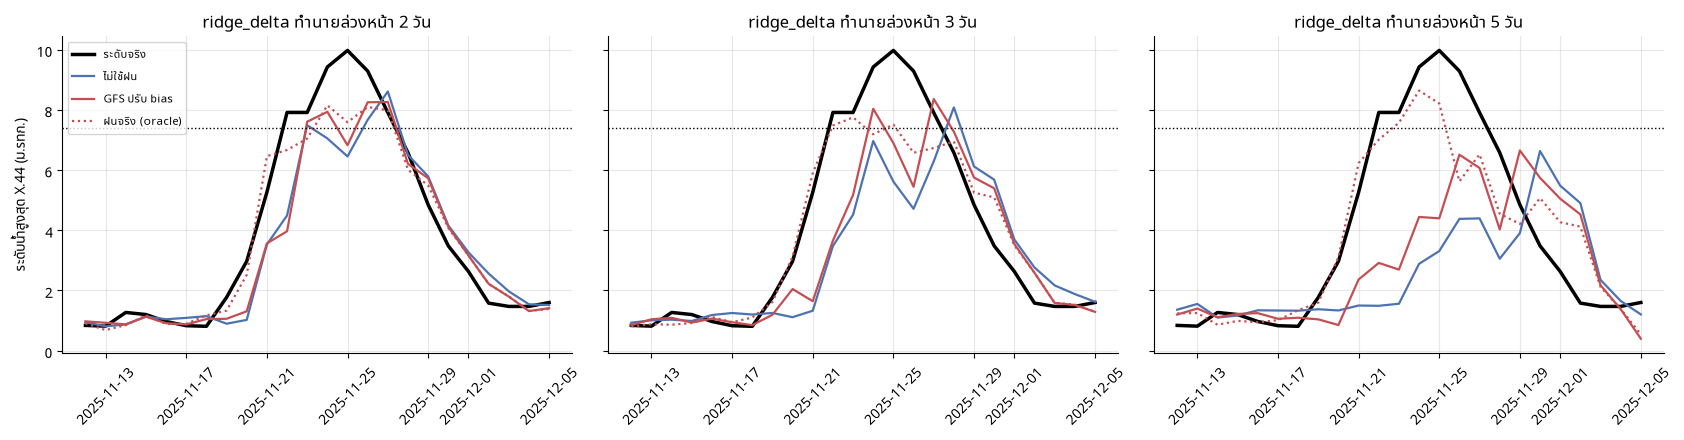

In [7]:
event = slice("2025-11-12", "2025-12-05")
actual = table["x44_max"].loc[event]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, h in zip(axes, (2, 3, 5)):
    ax.plot(actual.index, actual, color="k", lw=2.5, label="ระดับจริง")
    for input_name, color, style in [("ไม่ใช้ฝน", "#4c72b0", "-"), (CHOSEN_INPUT, "#c44e52", "-"), ("ฝนจริง (oracle)", "#c44e52", ":")]:
        shifted = test_predictions[("ridge_delta", input_name, h)].copy()
        shifted.index = shifted.index + pandas.Timedelta(days=h)
        ax.plot(shifted.loc[event], color=color, ls=style, lw=1.6, label=input_name)
    ax.axhline(evaluation.FLOOD_M, color="k", ls=":", lw=1)
    ax.set_title(f"ridge_delta ทำนายล่วงหน้า {h} วัน")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("ระดับน้ำสูงสุด X.44 (ม.รทก.)")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 4 · บันทึกโมเดลสำหรับเว็บ
- เทรนบนข้อมูลทั้งหมด (ใช้ฝน ERA5 จริงเป็น `rain_next{h}d` ตามแนวทาง perfect prognosis)
- horizon ที่ validation บอกว่าฝนไม่ช่วย ใช้โมเดลแบบไม่มีฝนแทน
- บันทึกแบบจำลองฝนที่เลือกและตัวคูณปรับ bias ไว้ใน manifest เพื่อให้ระบบ real-time สร้าง feature แบบเดียวกัน
- ความไม่แน่นอน (σ) คำนวณจาก error บน test ด้วยพยากรณ์ฝนจริง เก็บใน `uncertainty.json` คีย์ `ridge_delta_nwp`

In [8]:
TAG = "x44_ridge_delta_nwp"
nwp_model = next((m for m, label in NWP_MODELS.items() if CHOSEN_INPUT.startswith(label)), None)
everything = table.dropna(subset=["x44_max"])
final_models = []
for h in HORIZONS:
    if USE_RAIN[h]:
        rain_feature = f"rain_next{h}d"
        fit_frame = everything.assign(**{rain_feature: everything[f"oracle_rain_next{h}d"]})
        final_models.append(models.HorizonModel("ridge_delta", h, FEATURES + [rain_feature], BEST_PARAMS["ridge_delta"]).fit(fit_frame))
    else:
        final_models.append(models.HorizonModel("ridge_delta", h, FEATURES, BEST_PARAMS["ridge_delta"]).fit(everything))

rain_setup = {
    "input": CHOSEN_INPUT,
    # rain_next{h}d = mean over `nwp_models` of (raw forecast x scale when `scaled`)
    "nwp_models": [nwp_model] if nwp_model else list(NWP_MODELS),
    "scaled": "ปรับ bias" in CHOSEN_INPUT,
    "scale": {model: SCALE[model] for model in NWP_MODELS},
    "use_rain": USE_RAIN,
    "lead_offset": features.FORECAST_LEAD_OFFSET,
}
print("saved", models.save(final_models, TAG, extra={"rain": rain_setup}).relative_to(config.ROOT))

uncertainty_path = models.MODELS_DIR / "uncertainty.json"
uncertainty = json.loads(uncertainty_path.read_text())
uncertainty["ridge_delta_nwp"] = {
    h: evaluation.stage_split_rmse(
        test_predictions[("ridge_delta", CHOSEN_INPUT if USE_RAIN[h] else "ไม่ใช้ฝน", h)], test, h
    )
    for h in HORIZONS
}
uncertainty_path.write_text(json.dumps(uncertainty, indent=2))
pandas.DataFrame(uncertainty["ridge_delta_nwp"]).T.rename_axis("h")

saved data/models/x44_ridge_delta_nwp.json


,low,high,high_days
h,,,
1,0.176,0.929,8.0
2,0.304,1.357,8.0
3,0.383,2.203,8.0
4,0.445,2.817,9.0
5,0.497,3.271,9.0


## สรุป
**ความแม่นของพยากรณ์ฝน (มี.ค. 2024 – ปัจจุบัน)**
- ECMWF สัมพันธ์กับฝนจริงดีกว่า GFS (correlation 0.63–0.76 vs 0.55–0.69) แต่ทั้งคู่ **ให้ฝนหนักต่ำกว่าจริงมาก** —
  ในช่วงที่ฝนจริง ≥ 100 มม. พยากรณ์ได้แค่ 20–45% ของปริมาณจริง (พ.ย. 2568 ฝนจริง 3 วัน ~430 มม. พยากรณ์ได้ ~100–210 มม.)

**ผลต่อโมเดลระดับน้ำ (ridge_delta, MAE วันน้ำหลาก บน test)**

| h | ไม่ใช้ฝน | + พยากรณ์ฝน GFS ปรับ bias | ฝนจริง (เพดาน) |
|---|---|---|---|
| 1 | **0.68** | 0.80 | 0.59 |
| 2 | 1.65 | **1.47** | 1.05 |
| 3 | 3.06 | **2.33** | 1.18 |
| 4 | 4.14 | **3.10** | 1.47 |
| 5 | 4.73 | **3.63** | 1.39 |

- **ล่วงหน้า 3–5 วันดีขึ้น 23–25%** และเริ่มเตือน ≥ 7.40 ม. ได้ล่วงหน้า 3 วัน (2 / 6 วัน) และ 4 วัน (1 / 6) โดยไม่มีเตือนผิดที่ h=3
- ล่วงหน้า 1 วันแย่ลงเล็กน้อย (validation บอกให้ใช้ฝนทุก horizon แต่ test กลับไม่ช่วยที่ h=1) — ข้อมูลน้ำต้นน้ำสำคัญกว่าฝนพยากรณ์ในระยะสั้น
- ยังห่างจากเพดาน (ฝนจริง) มาก → **ข้อจำกัดหลักคือความแม่นของพยากรณ์ฝนเอง** ไม่ใช่ตัวโมเดลระดับน้ำ

**บันทึกไว้:** `data/models/x44_ridge_delta_nwp*` (manifest มีแบบจำลองฝนและตัวคูณ bias) และ σ ใน `uncertainty.json` คีย์ `ridge_delta_nwp`

**ต่อยอดได้:** ใช้ ensemble 51 สมาชิกของ ECMWF เพื่อคิดความน่าจะเป็นฝนหนัก, ปรับ bias แบบ quantile mapping เมื่อมีข้อมูลพยากรณ์ยาวขึ้น